<a href="https://colab.research.google.com/github/j-c-stuifbergen/AP3531-homework-1/blob/main/AP3531_Assignment_1D_J_C_Stuifbergen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home work 1D

In [1]:
#@title #Import packages that are required
import numpy as np
import matplotlib.pyplot as plt
import math, cmath

In [2]:
#@title ##Ricker wavelet function

def Ricker(f0,t0,t):
  mu = (np.pi**2)*(f0**2)*((t-t0)**2)
  return (1-2*mu)*np.exp(-mu)



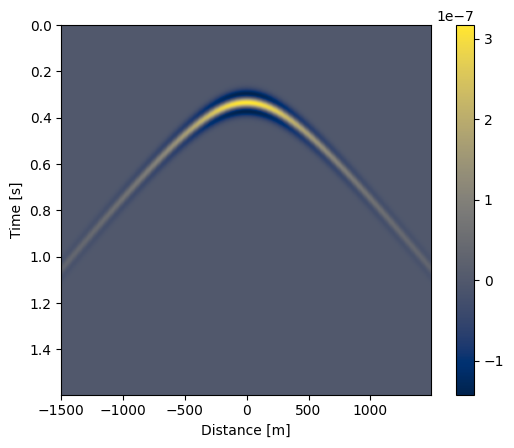

In [3]:
# @title #seismic signal (from exercise 1B)

# x=−1000m to x=+990 m with a spatial sampling of 20 m (i.e. 100 signals
# in the x-direction) and 256 samples in the time direction with t=4ms.
# create the x-axis, assuming dx=25m and center is x=0
xmin=-1500 # meter
xmax = 1490 # meter
dx=10
nx=math.ceil((xmax-xmin)/(2*dx))*2 # make it an even number
xaxis=xmin+np.arange(nx)*dx
xmax = xaxis[-1]

f0 = 10 # Hz
v = 1500 # m/s
tmin = 0
dt = 0.004
nt = 400
taxis = tmin+np.arange(nt)*dt
tmax = taxis[-1]

z = 500
z2 = z*z
data=np.zeros((nx,nt))
for ix in range(nx):
    distance = math.sqrt(pow(xaxis[ix],2)+z2)
    delay = distance/v
    amplitude = 1/(4*np.pi*pow(distance,2))
    for it in range(nt):
        data[ix,it]=amplitude * Ricker(f0,0,taxis[it]-delay)

# Plotting the 2D array as grey-level image; plot transpose to get the time-axis downward
# the aspect value is to make sure the plot is a rectanlge (try without).
plt.figure()
plt.imshow(data.T,cmap='cividis',extent=[xmin,xmax,tmax, tmin], aspect = (-xmin+xmax)/(tmax-tmin))
plt.xlabel("Distance [m]")
plt.ylabel("Time [s]")
plt.colorbar()
plt.show()

(300, 400)


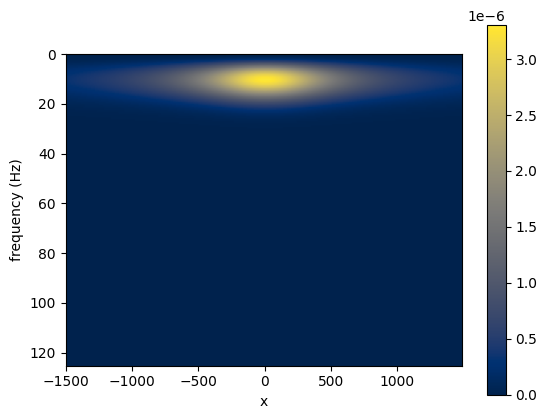

In [4]:
# @title Px0Z0 - the Fourier transform in the time domain
#
print(data.shape)
# 𝑃(𝑥, 𝜔; 𝑧0)
PxZ0=np.fft.rfft(data) # real Fourier transform over last index (=time index)
#PxZ0=np.fft.rfft2(data) # real Fourier transform over last index (=time index)
#
plt.figure()
plt.imshow(np.abs(PxZ0.T)
           ,cmap='cividis'
  ,extent=[xmin,xmax,nt/(-tmin+tmax)/2,0]
, aspect = 3/(-tmin+tmax)*(-xmin+xmax)/nx)
plt.xlabel("x")
plt.ylabel("frequency (Hz)")
plt.colorbar()
plt.show()


201
[0.        3.9368329 7.8736658]


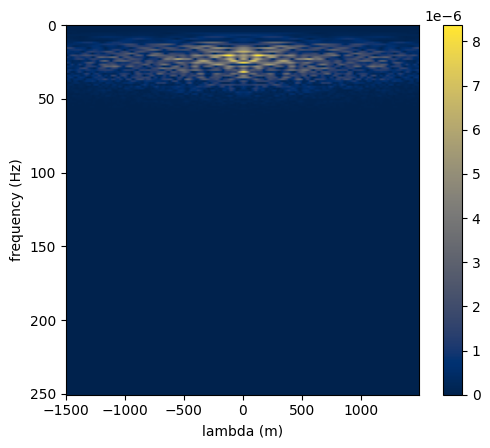

In [5]:
# @title the Raleigh transform
# Example to make the FK plot of the 2D array
#print(PxZ0[:3,:3])
nOmega = PxZ0.shape[1]
print(nOmega)
Raleigh=np.zeros((nx,nOmega),dtype=np.complex128)
f = np.arange(nOmega)*1/(tmax-tmin)
omega =  1*2*np.pi * f
print(omega[:3])
for ix0 in range(nx):
    for ixA in range(nx):
        R = math.sqrt(pow(xaxis[ix0]-xaxis[ixA],2)+z2)
        cosPhi = z/R
        #for it in range(nt):
        factor = np.sqrt(f[:]/R)*cosPhi

        Raleigh[ix0,:]+=factor*np.exp(1j*R*omega[:])*PxZ0[ixA,:]

plt.figure()
plt.imshow((np.abs((Raleigh.T)))
           ,cmap='cividis'
  ,extent=[xmin,xmax,nt/(-tmin+tmax),0]
          ,  aspect = 2/(-tmin+tmax)*(-xmin+xmax)/nx)
plt.xlabel("lambda (m)")
plt.ylabel("frequency (Hz)")
plt.colorbar()
plt.show()


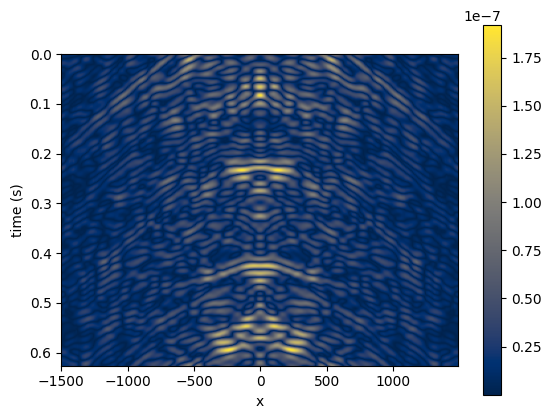

In [6]:
# @title the back-transformation (FFT over the frequency)
# 𝑃(𝑥A, 𝜔; zA)

result=np.fft.irfft(Raleigh) # inverse Fourier transform over last index (=time index)

plt.figure()
plt.imshow((np.abs((result.T)))
           ,cmap='cividis'
  ,extent=[xmin,xmax,1/(-tmin+tmax),0]
, aspect = 2/(-tmin+tmax)*(-xmin+xmax))
plt.xlabel("x")
plt.ylabel("time (s)")
plt.colorbar()
plt.show()
